In [ ]:
from dlfs.layers import EmbeddingLayer, PositionalEncoding, DenseLayer
from dlfs.modules import TransformerEncoder

from dlfs.activation import ReLU, Sigmoid
from dlfs.loss import BCE_Loss
from dlfs.optimizers import Optimizer_Adam

from dlfs.base import Module

import numpy as np

In [236]:
def generate_encoder_dataset(num_samples=1000, seq_length=5, vocab_size=10):
    """
    Generate a dataset for classification based on sum of sequence.
    - If the sum of the sequence is even, label is 0.
    - If the sum of the sequence is odd, label is 1.
    """
    # Generate random sequences of integers
    X = np.random.randint(1, vocab_size, size=(num_samples, seq_length))
    
    # Compute the sum of each sequence
    sequence_sums = np.sum(X, axis=1)
    
    # Generate binary labels: 0 if sum is even, 1 if sum is odd
    y = sequence_sums % 2  # 0 for even sum, 1 for odd sum
    
    return X, y

def get_random_batch(X, y, batch_size):
    idx = np.random.randint(0, len(X), size=(batch_size, ))
    return X[idx], y[idx]

In [237]:
class TransformerEncoderModel(Module):

    def __init__(self, vocab_size=12, block_size=5, 
                       n_embed=512, n_head = 4, n_enc_layers=2, dim_ff=2048,
                       dropout=0.1, activation=ReLU(), layer_norm_eps=1e-5, loss_function=None, optimizer=None):
        
        self.loss_function = loss_function
        self.optimizer = optimizer

        self.embed_enc = EmbeddingLayer(vocab_size, n_embed)
        self.pos_enc_enc = PositionalEncoding(block_size, n_embed)

        self.encoder = TransformerEncoder(d_model=n_embed, n_head=n_head, n_enc_layers=n_enc_layers,
                                          dim_ff=dim_ff, dropout=dropout, activation=activation, layer_norm_eps=layer_norm_eps)

        self.linear = DenseLayer(n_embed, 1)
        self.sigm = Sigmoid()

    def forward(self, inputs_enc, training):

        self.embed_enc.forward(inputs_enc, training)

        self.pos_enc_enc.forward(self.embed_enc.output, training)

        self.encoder.forward(self.pos_enc_enc.output, training)

        pooled_output = np.mean(self.encoder.output, axis=1)  # Shape: (batch_size, d_model)

        self.linear.forward(pooled_output, training)

        self.sigm.forward(self.linear.output, training)

        self.output = self.sigm.output

    def backward(self, output, y):

        self.loss_function.backward(output, y)

        self.sigm.backward(self.loss_function.dinputs)

        self.linear.backward(self.sigm.dinputs)

        batch_size, seq_len, d_model = self.encoder.output.shape
        # Calculate the gradient w.r.t. the pooled output
        depooled_gradients = np.repeat(self.linear.dinputs, seq_len, axis=1) / seq_len  # Shape: (batch_size, seq_len, d_model)
        depooled_gradients = depooled_gradients.reshape(batch_size, seq_len, d_model)

        self.encoder.backward(depooled_gradients)

        self.pos_enc_enc.backward(self.encoder.dinputs)
        self.embed_enc.backward(self.pos_enc_enc.dinputs)

    def train(self, X, y_true, epochs = 1000, batch_size: int = None, print_every: int = None):

        self.loss_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:

                batch_loss = 0

                for j in range(0, len(X), batch_size):

                    # Subset data into a batch
                    batch_X = X[j:j+batch_size, :]
                    batch_y = y_true[j:j+batch_size]

                    # Forward pass
                    self.forward(batch_X, training=True)

                    batch_loss += self.loss_function.calculate(self.output, batch_y)

                    # Backward pass
                    self.backward(self.output, batch_y)

                    self.optimizer.pre_update_parameters()
                    self.optimizer.update_parameters(self)
                    self.optimizer.post_update_parameters()

                self.loss_vals.append(batch_loss / (len(X) // batch_size))

                if print_every is not None and not i % print_every:
                    print(f'===== EPOCH : {i} ===== LOSS : {batch_loss / (len(X) // batch_size)} =====')

            else:
                self.forward(X, training=True)
                self.backward(self.output, y_true)

                self.optimizer.pre_update_parameters()
                self.optimizer.update_parameters(self)
                self.optimizer.post_update_parameters()

                loss = self.loss_function.calculate(self.output, y_true)
                self.loss_vals.append(loss)

                if print_every is not None and not i % print_every:
                    print(f'===== EPOCH : {i} ===== LOSS : {loss} =====')
                
    def predict(self, X):
        self.forward(X)
        return self.output > 0.5

In [238]:
X_train, y_train = generate_encoder_dataset(num_samples=100)
y_train = y_train.reshape(-1, 1)
              
print(X_train[:5])
print(y_train[:5])

[[9 7 7 9 7]
 [9 7 2 4 3]
 [2 9 4 2 5]
 [7 1 6 4 1]
 [6 2 8 4 9]]
[[1]
 [1]
 [0]
 [1]
 [1]]


In [239]:
#np.random.seed(1)

vocab_size = max(max(X_train.flatten()), max(y_train.flatten())) + 1
block_size = X_train.shape[-1]
batch_size = None

n_embed = 64
n_head = 8
n_enc_layers = 2
dim_ff = 128
dropout = 0.
eps = 1e-5

epochs = 20000
lr = 1e-4

loss = BCE_Loss()
optimizer = Optimizer_Adam(learning_rate=lr, decay=0., clip_grad=False)

model = TransformerEncoderModel(vocab_size=vocab_size, 
                         block_size=block_size, 
                         n_embed=n_embed, 
                         n_head=n_head,
                         n_enc_layers=n_enc_layers,
                         dim_ff=dim_ff, 
                         dropout=dropout,
                         layer_norm_eps=eps,
                         loss_function=loss, 
                         optimizer=optimizer)

model.train(X_train, y_train, print_every=50, epochs=epochs, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS : 1.2395287959731216 =====
===== EPOCH : 50 ===== LOSS : 3.1682924137349833 =====
===== EPOCH : 100 ===== LOSS : 2.393495816974591 =====
===== EPOCH : 150 ===== LOSS : 1.4487430088529392 =====
===== EPOCH : 200 ===== LOSS : 0.7360655988603264 =====
===== EPOCH : 250 ===== LOSS : 0.6732324074510432 =====
===== EPOCH : 300 ===== LOSS : 0.6675667857741736 =====
===== EPOCH : 350 ===== LOSS : 0.6772405988800472 =====
===== EPOCH : 400 ===== LOSS : 0.688081110682664 =====
===== EPOCH : 450 ===== LOSS : 0.6675756969065758 =====
===== EPOCH : 500 ===== LOSS : 0.708752788637731 =====
===== EPOCH : 550 ===== LOSS : 0.5334721664128454 =====
===== EPOCH : 600 ===== LOSS : 0.5713945924334827 =====
===== EPOCH : 650 ===== LOSS : 0.4917754968896331 =====
===== EPOCH : 700 ===== LOSS : 0.4193976608872007 =====
===== EPOCH : 750 ===== LOSS : 0.35133164111377774 =====
===== EPOCH : 800 ===== LOSS : 0.33233138280466307 =====
===== EPOCH : 850 ===== LOSS : 0.27177735433729167 =

KeyboardInterrupt: 

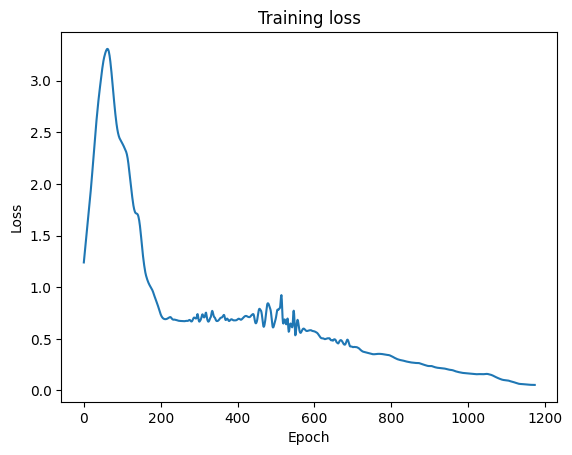

In [252]:
import matplotlib.pyplot as plt

plt.plot(range(len(model.loss_vals)), model.loss_vals)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [255]:
model.forward(X_train, training=False)
result = (model.output > 0.5).astype(int)

print(result[:10].reshape(-1))
print(y_train[:10].reshape(-1))
print(f'Accuracy: {np.mean(y_train == result)}')

[1 1 0 1 1 1 1 1 0 1]
[1 1 0 1 1 1 1 1 0 1]
Accuracy: 0.98


In [262]:
X_test, y_test = generate_encoder_dataset(num_samples=10)
model.forward(X_test, training=False)
result = (model.output > 0.5).astype(int)

print(result[:5].reshape(-1))
print(y_train[:5].reshape(-1))
print(f'Accuracy: {np.mean(y_test == result)}')

[1 1 1 0 1]
[1 1 0 1 1]
Accuracy: 0.5
